In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import scipy.signal
from scipy.signal import find_peaks, spectrogram, hilbert, spectrogram
from matplotlib.patches import Patch
from TIF import Info, Anotaciones, RawSignal, EEGSignal, ECGSignal, EMGSignal

**Pruebas clase Info**

In [75]:
canales = ["F2", "F3"]
tipos_canales = ["eeg"] * len(canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

vecinos = {"F2":["F3"]}

In [76]:
info = Info("Juan Acosta", sujeto, canales, tipos_canales, None, "Pruebita", 512, neighbors=vecinos)
# print(info.__contains__("Experimentador"))

print("Nombre del experimentador:",info.__getitem__("Experimentador"))

print(info.__len__())  # Cantidad de elementos almacenados

print(info.keys()) 

print(info.item("Experimentador"))
print(info.item("Nombre canales"))
print(info.keys())
print(info.item("Vecinos"))  

Nombre del experimentador: Juan Acosta
8
['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo', 'Vecinos']
('Experimentador', 'Juan Acosta')
('Nombre canales', ['F2', 'F3'])
['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo', 'Vecinos']
('Vecinos', {'F2': ['F3']})


In [77]:
# Elimino elementos de una clave (en este caso de los canales)
info.eliminar_elementos(key="Nombre canales", elementos=["F3"])

In [78]:
print(info.item("Nombre canales"))

('Nombre canales', ['F2'])


**Pruebas clase Anotaciones**

In [79]:
inicio = [5.0, 12.5, 20.0]
duracion = [2.0, 3.0, 3.5]
descripcion = ['Inicio_Experimento', 'Evento_1', 'Evento_2']

In [80]:
anotaciones = Anotaciones(onset=inicio, duration=duracion, description=descripcion)

In [81]:
anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
0,5.0,2.0,Inicio_Experimento
1,12.5,3.0,Evento_1
2,20.0,3.5,Evento_2


In [82]:
# Agrego una anotación
nueva_anotacion = [3, 4, "Evento 3"]
anotaciones.add(nueva_anotacion)

True

In [83]:
anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
0,5.0,2.0,Inicio_Experimento
1,12.5,3.0,Evento_1
2,20.0,3.5,Evento_2
3,3.0,4.0,Evento 3


In [84]:
# Genero una instancia anotaciones desde un csv
anotaciones_csv = Anotaciones(file="../2. Datos prueba/emg/eventos_emg.csv")
anotaciones_csv.get_annotations().head()

,Inicio,Duracion,Descripcion
0,36.265625,5,2
1,52.792969,5,1
2,70.972656,5,1
3,86.386719,5,1
4,104.843750,5,2


**Pruebas clase RawSignal**

In [85]:
eeg_data = np.load("../2. Datos Prueba/eeg/eeg_signal.npy")

In [86]:
eeg_data.shape

(62, 388047)

In [87]:
# Esto era para ver nomas que habia en el archivo
eeg = pd.DataFrame(eeg_data)
eeg.head()

,0,1,2,3,4,5,6,7,8,9,...,388037,388038,388039,388040,388041,388042,388043,388044,388045,388046
0,3.058463,69.378151,512.287476,2046.245483,5376.158691,10384.538086,15923.265625,20547.367188,23392.972656,24475.962891,...,-178.895386,-173.085815,-164.276978,-152.824463,-141.760376,-135.108521,-135.037842,-141.609375,-154.146606,-171.841797
1,2.483788,56.613033,418.650482,1673.291016,4397.784668,8496.500000,13029.791992,16814.097656,19141.298828,20024.503906,...,-34.890717,-32.244675,-26.992029,-20.398066,-14.261873,-10.162393,-8.862572,-10.432716,-14.530706,-20.378460
2,1.720225,39.700825,294.783447,1180.238525,3104.773193,6001.839844,9207.491211,11883.846680,13528.648438,14150.855469,...,-172.516739,-169.558792,-165.001038,-154.812500,-138.597839,-121.553047,-111.058151,-111.978516,-124.081688,-142.575546
3,2.277081,85.158783,690.347961,2849.392334,7594.347656,14776.036133,22754.841797,29451.494141,33609.718750,35234.156250,...,-101.200439,-109.095215,-101.527100,-79.137939,-51.548828,-31.460693,-26.456543,-36.743652,-58.282227,-85.846191
4,2.820107,69.279091,522.174072,2102.081055,5542.711914,10726.230469,16464.289062,21257.328125,24206.724609,25327.796875,...,-33.257740,-30.782782,-25.127575,-17.920855,-11.455353,-7.688463,-7.410977,-10.375611,-15.825042,-22.785292


In [88]:
# Genero objeto Info

canales = range(1,63)

nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
# canales = ["F2", "F3", "F4"]
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

infoo = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=nombre_canales, 
        ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Claves:", infoo.keys())
print("Canales iniciales:", infoo.data["Nombre canales"])

Claves: ['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo']
Canales iniciales: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


In [89]:
# Genero objeto Anotaciones, mediante anotaciones "manuales"

inicio = [5.0, 12.5, 20.0]
duracion = [2.0, 3.0, 3.5]
descripcion = ['Inicio_Experimento', 'Evento_1', 'Evento_2']
anotacioness = Anotaciones(onset=inicio, duration=duracion, description=descripcion)
anotacioness.get_annotations()

,Inicio,Duracion,Descripcion
0,5.0,2.0,Inicio_Experimento
1,12.5,3.0,Evento_1
2,20.0,3.5,Evento_2


In [90]:
# Generar el objeto RawSignal
raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness) 
raw_signal.data[1]

array([  2.483788,  56.613033, 418.65048 , ..., -10.432716, -14.530706,
       -20.37846 ], dtype=float32)

In [91]:
# Método __getitem__() pasando el nombre de un solo canal
raw_signal["3"]

array([   1.7202253,   39.700825 ,  294.78345  , ..., -111.978516 ,
       -124.08169  , -142.57555  ], dtype=float32)

In [92]:
# Método __getitem__() pasando una lista de canales

raw_signal[["3","4"]]

array([[   1.7202253,   39.700825 ,  294.78345  , ..., -111.978516 ,
        -124.08169  , -142.57555  ],
       [   2.277081 ,   85.15878  ,  690.34796  , ...,  -36.743652 ,
         -58.282227 ,  -85.84619  ]], dtype=float32)

In [93]:
# Método __getitem__() pasando un slice con las muestras

raw_signal[512:1024].shape
raw_signal[512:1024]

array([[2473.9521  , 2500.9302  , 2526.8242  , ..., -855.665   ,
        -875.47424 , -892.69824 ],
       [2023.509   , 2047.4478  , 2070.1316  , ..., -696.74054 ,
        -711.33405 , -723.87585 ],
       [1427.2146  , 1446.2266  , 1464.0992  , ..., -488.34012 ,
        -497.71823 , -505.50653 ],
       ...,
       [1324.9893  , 1336.75    , 1349.3641  , ..., -469.35852 ,
        -474.30624 , -479.03287 ],
       [2033.8102  , 2059.245   , 2083.7175  , ..., -692.9624  ,
        -707.23047 , -720.15784 ],
       [-147.31554 , -146.39122 , -145.79912 , ...,   60.074905,
          65.6089  ,   70.09646 ]], dtype=float32)

In [94]:
# Método __getitem__() pasando una lista de canales y un slice para las muestras

raw_signal[(["1","2"], slice(512, 1024))].shape

(2, 512)

In [95]:
# Obtener muestas con get_data()

# muestras = raw_signal.get_data(start=0, stop=1)   # Sin pasar los canales los selecciona a todos
# muestras, vector = raw_signal.get_data(picks=[0,1,2], start=0, stop=10, times=True, reject=30000)
# print(muestras.shape)
# print(vector)

muestras = raw_signal.get_data(picks=["1","2", "3"], start=0, stop=20)  
print(muestras.shape)

(3, 10240)


In [96]:
# Elimina el canal "F2"
nueva_rawsignal = raw_signal.drop_channels(["1"])

In [97]:
# Verifico que la nueva instancia de RawSignal elimino un canal
print("Canales restantes:", nueva_rawsignal.info["Nombre canales"])

Canales restantes: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


In [98]:
datos = nueva_rawsignal.describe("Datos.csv")
datos

,2,3,4,5,6,7,8,9,10,11,...,53,54,55,56,57,58,59,60,61,62
Nombre canal,2,3,4,5,6,7,8,9,10,11,...,53,54,55,56,57,58,59,60,61,62
Tipo canal,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,...,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg
Min,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,-5470.771484,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,-5.745003,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,-0.00844,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,4.314002,5.865489,13.503281,5.290212,4.608644,4.702813,5.650655,5.634275,5.804526,5.765774,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,15524.520508,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


In [99]:
nueva_rawsignal.data.shape

(61, 388047)

In [100]:
# Uso la nueva instancia RawSignal y selecciono dos canales 
print(nueva_rawsignal.get_data(picks=["3", "4"], start=0, stop=10).shape)

(2, 5120)


In [101]:
# Recortar la señal (tiempo). Método crop() desde el primer objeto Rawsignal

rawsignal_recortada = raw_signal.crop(tmin= 5, tmax=50)   # Recorte
datos, tiempo = rawsignal_recortada.get_data(picks=["2", "3"], start=0, stop=5, times=True)
print(datos.shape)
print("Vector temporal:", tiempo)

(2, 2560)
Vector temporal: [5.         5.00195312 5.00390625 ... 9.99414062 9.99609375 9.99804688]


In [102]:
# Metodo describe() con la primar instancia de RawSignal que tiene el Objeto Info

raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness)
# muestras = raw_signal_2.get_data(picks=["A2", "F3"], start=0, stop=100)
datos = raw_signal.describe("Datos.csv")
datos

,1,2,3,4,5,6,7,8,9,10,...,53,54,55,56,57,58,59,60,61,62
Nombre canal,1,2,3,4,5,6,7,8,9,10,...,53,54,55,56,57,58,59,60,61,62
Tipo canal,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,...,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,7.569031,4.314002,5.865489,13.503281,5.290212,4.608644,4.702813,5.650655,5.634275,5.804526,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


In [103]:
# Metodo describe() sin el Objeto Info. Si no le paso este objeto veo todos los canales y el Tipo de canal se establece en desconocido

raw_signal_sinInfo = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)
datos2 = raw_signal_sinInfo.describe("Datos2.csv")
datos2

,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,Canal_10,...,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61,Canal_62
Nombre canal,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,Canal_10,...,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61,Canal_62
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,...,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,7.569031,4.314002,5.865489,13.503281,5.290212,4.608644,4.702813,5.650655,5.634275,5.804526,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


In [104]:
# Metodo pick()

canales = range(1,63)

nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

info2 = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=nombre_canales,
            ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Canales iniciales:", info2.data["Nombre canales"])
print()

raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, info=info2, anotaciones=anotacioness)

# Aca se genera el subset con el metodo pick()
subset = raw_signal_2.pick(canales=["2", "62"])            # Le pasamos los canales que queremos en una lista (canales)
print("Canales del subset:", subset.info["Nombre canales"])
datos = subset.describe("Datoss.csv")                       # Usamos describe para ver algunos datos del subset
datos

Canales iniciales: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']

Canales del subset: ['2', '62']


,2,62
Nombre canal,2,62
Tipo canal,eeg,eeg
Min,-7117.736328,-1448.569214
Q1,-4.250395,-2.563532
Mediana,0.011847,0.02015
Q3,4.314002,2.606564
Max,20024.503906,3067.844727


In [105]:
# Metodo pick(). Sin el objeto Info (toma los 62 canales) y usando "slice" selecciona algunos

raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)

subset = raw_signal_2.pick(slice=[0,6])       # Obtenemos los canales de 0 a 4. (El 4 no se incluye)
# subset = raw_signal_2.pick(canales=[0,2,4])
asd = subset.get_data()
asd.shape
datos = subset.describe("Datoss.csv")   # Vemos algunos datos de los canales seleccionados 
datos

,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6
Nombre canal,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739
Q3,7.569031,4.314002,5.865489,13.503281,5.290212,4.608644
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391


In [106]:
# Generamos un nuevo onjeto Anotaciones. Esta vez se cargan desde un archivo csv
anotaciones_file = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")
anotaciones_file.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


In [107]:
# Cambiamos las anotaciones RawSignal
raw_signal_2.set_anotaciones(anotaciones_file)

In [108]:
# Instanciamos otro objeto RawSignal. Le pasamos Info y las Anotaciones que cargamos del archivo
signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotaciones_file)

# Vemos algunas de las anotaciones
signal.anotaciones.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


In [109]:
# Recortamos "signal"
recorte_señal = signal.crop(tmin=35, tmax=60)
# recorte_señal.info.get("Nombre canales")

In [110]:
# Vemos el vector de tiempo para verificar que recortamos la señal 
d, t = recorte_señal.get_data(picks=["2"], times=True)
t

array([35.        , 35.00195312, 35.00390625, ..., 59.99414062,
       59.99609375, 59.99804688])

In [111]:
# Verificamos que tambien se recortaron las anotaciones 
recorte_señal.anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA


In [112]:
print("first_samp:", recorte_señal.first_samp)
print("sfreq:", recorte_señal.sfreq)
print("Duración de la señal :", recorte_señal.data.shape[1] / recorte_señal.sfreq)

first_samp: 35
sfreq: 512
Duración de la señal : 25.0


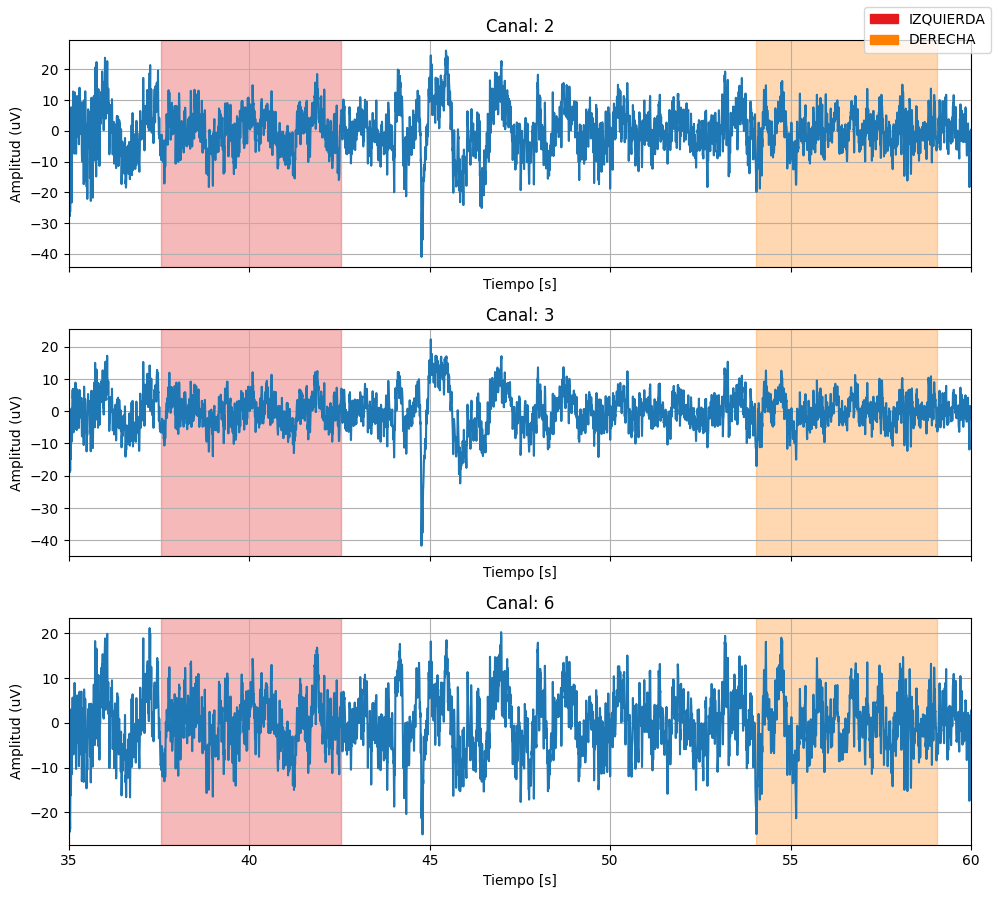

In [113]:
# Gráficamos nuestra señal recortada
recorte_señal.plot(picks=["2","3", "6"], show_anotaciones=True)

In [114]:
# Filtramos la señal
filtrada = recorte_señal.filter(l_freq=20, h_freq=100)

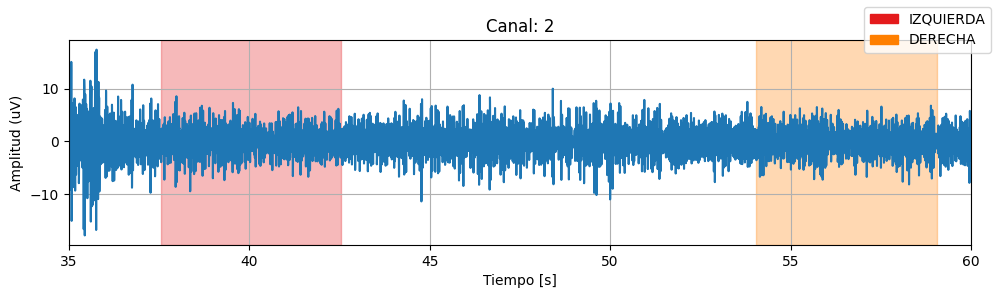

In [115]:
# Graficarmos la señal filtrada
filtrada.plot(picks=["2"])

**Pruebas para la clase EEG**

In [116]:
import json

with open("../2. Datos Prueba/eeg/eeg_vecinos.json", "r") as f:
    vecinos = json.load(f)

canales = range(1,63)
nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

# Generamos el objeto Info

info_eeg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512, neighbors=vecinos )

anotaciones_file = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")

eeg_data = np.load("../2. Datos Prueba/eeg/eeg_signal.npy")

In [117]:
# Instanciar clase EEG

eeg = EEGSignal(data=eeg_data, sfreq=512, info=info_eeg, anotaciones=anotaciones_file, first_samp=0, referencia="canal", canal="1")

In [118]:
eeg.data_ref[0]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [119]:
# Le cambio la referencia a un canal
ref = eeg.set_reference(reference="canal", channel="2")
ref.shape
ref[0]

array([   0.5746753,   12.765118 ,   93.63699  , ..., -131.17667  ,
       -139.6159   , -151.46333  ], dtype=float32)

In [120]:
ref_laplaciana = eeg.set_reference("laplaciano")
ref_laplaciana[0]

array([   0.3132112,    5.108612 ,   33.645447 , ..., -134.44702  ,
       -142.15036  , -153.25374  ], dtype=float32)

In [121]:
ref_promedio = eeg.set_reference(reference="promedio")
ref_promedio.shape
ref_promedio[0]

array([   1.493839,   26.415298,  181.00632 , ..., -131.14218 ,
       -136.10907 , -145.36543 ], dtype=float32)

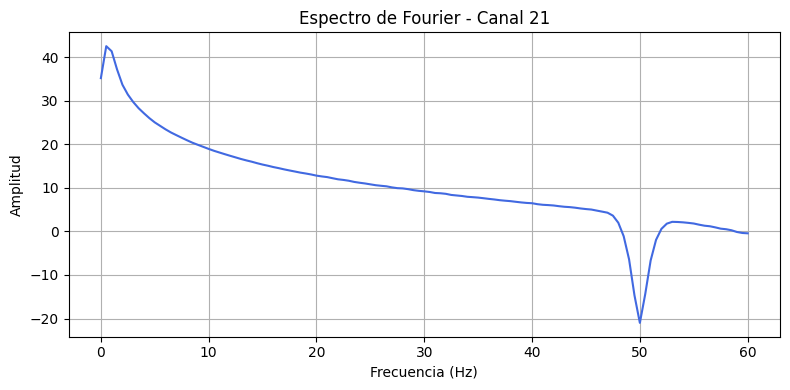

In [122]:
frec, espectro = eeg.espectro_frecuencias(picks=["21"],plot=True, fmin=0, fmax=60)

In [123]:
eeg_filtrada = eeg.filter(l_freq=0.1, h_freq=40)

In [124]:
eeg_filtrada_recortada = eeg_filtrada.crop(tmin=20, tmax=45)

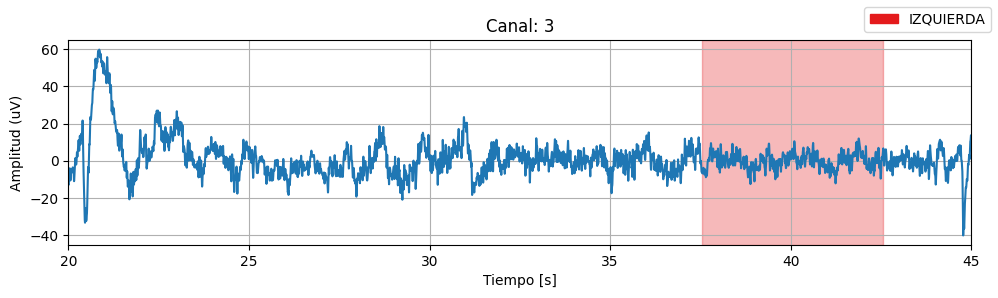

In [125]:
eeg_filtrada_recortada.plot(picks=["3"])

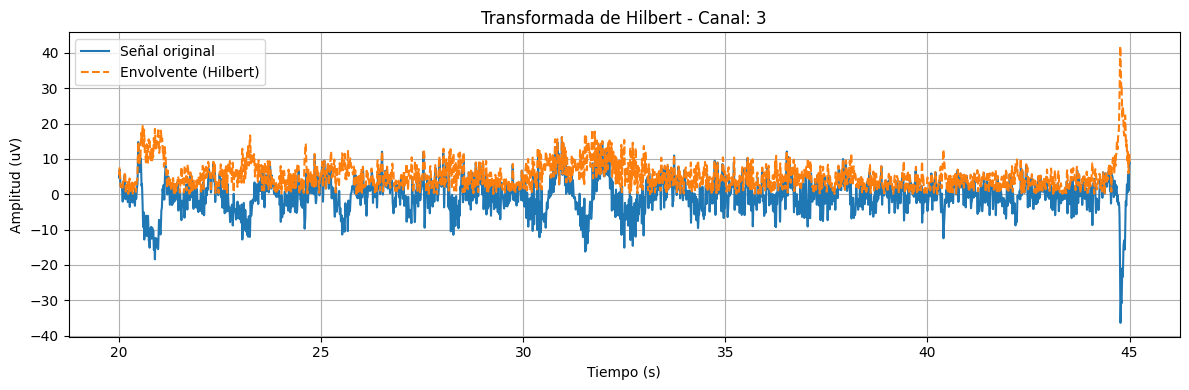

In [126]:
e = eeg_filtrada_recortada.plot_hilbert_transform(picks=["3"])

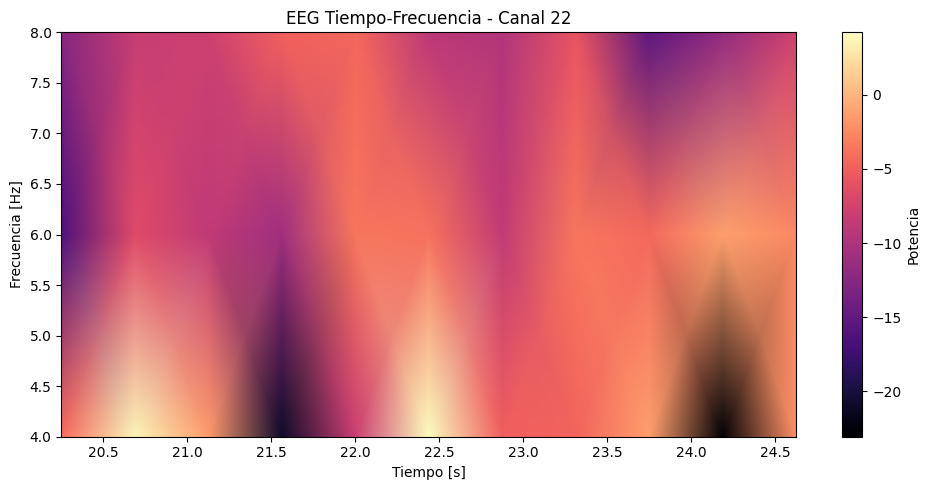

In [127]:
eeg_filtrada_recortada.plot_time_frequency(canal="22", fmin= 4,fmax=8, start_time=20, end_time=25, absoluto=True)

**Pruebas para la clase ECG**

In [128]:
# Cargar la señal
ecg_data = np.load("../2. Datos Prueba/ecg/ecg.npy")

In [129]:
ecg_data.shape

(388971,)

In [130]:
nombre_canales = ["1"]
    
tipos_canales = ["ecg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

# Generamos el objeto Info

info_ecg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512)

anotaciones_file = Anotaciones(file="../2. Datos Prueba/ecg/eventos_ecg.csv")

In [131]:
ecg = ECGSignal(data=ecg_data, sfreq=510, info=info_ecg, anotaciones=anotaciones_file)

In [132]:
picos = ecg.detectar_r_peaks(canales=["1"], start=5, end=15)
print(f"Picos R detectados: {len(picos[0])}")

Picos R detectados: 15


In [133]:
# Calcular frecuencia cardíaca
fc = ecg.calcular_hr()
print(f"Frecuencia cardíaca promedio: {fc[0]:.2f} bpm")

Frecuencia cardíaca promedio: 85.22 bpm


In [134]:
# Filtramos la señal
ecg_filtrada = ecg.filter(l_freq=1, h_freq=100, notch_freq=50)

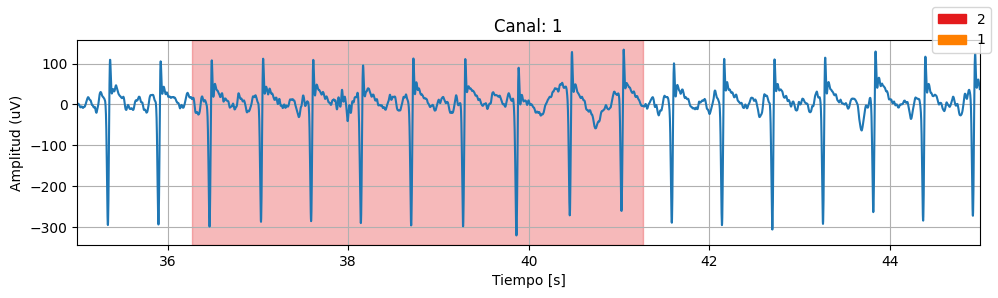

In [135]:
# Gráfica de la señal de ECG filtrda
ecg_filtrada.plot(start=35, duration=10)

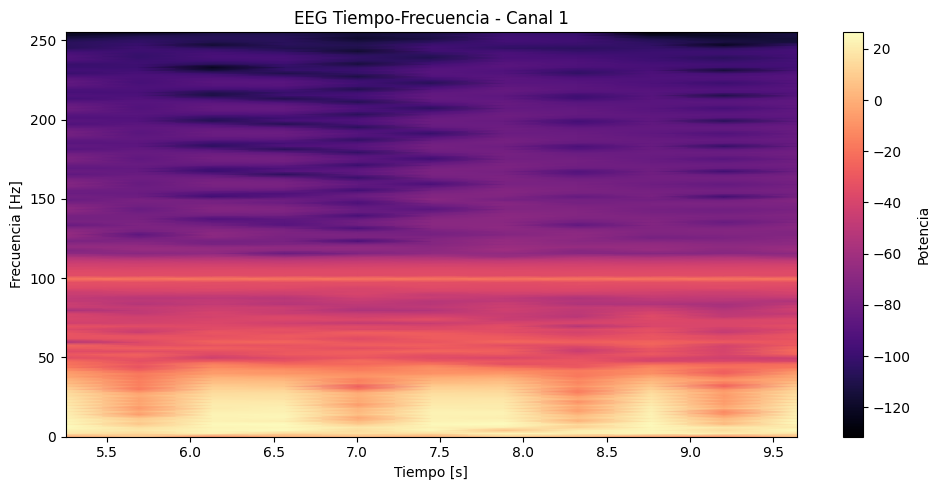

In [136]:
ecg_filtrada.plot_time_frequency(canal="1", start_time=5, end_time=10)

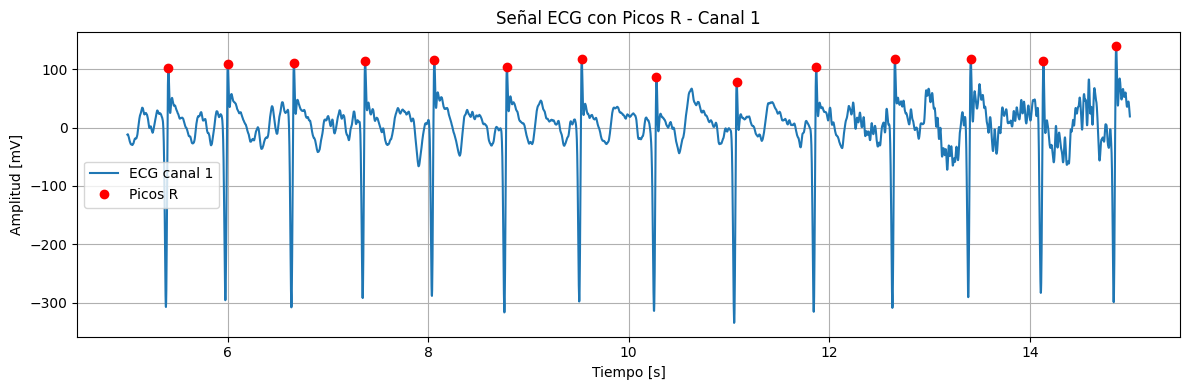

In [137]:
# Graficar la señal con picos R
ecg_filtrada.plot_r_peaks(picks=["1"],start=5, end=15)

**Pruebas para la clase EMG**

In [138]:
# Cargar datos
emg_data = np.load("../2. Datos Prueba/emg/emg.npy")

In [139]:
emg_data.shape

(388971,)

In [140]:
nombre_canales = ["1"]
    
tipos_canales = ["emg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

# Generamos el objeto Info

info_emg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512)

anotaciones_file = Anotaciones(file="../2. Datos Prueba/emg/eventos_emg.csv")

In [141]:
emg = EMGSignal(emg_data, sfreq=1000, info=info_emg, anotaciones=anotaciones_file, umbral_microv=2000)

In [142]:
# Filtramos la señal
emg_filtrada = emg.filter(l_freq=1, h_freq=60, notch_freq=50)

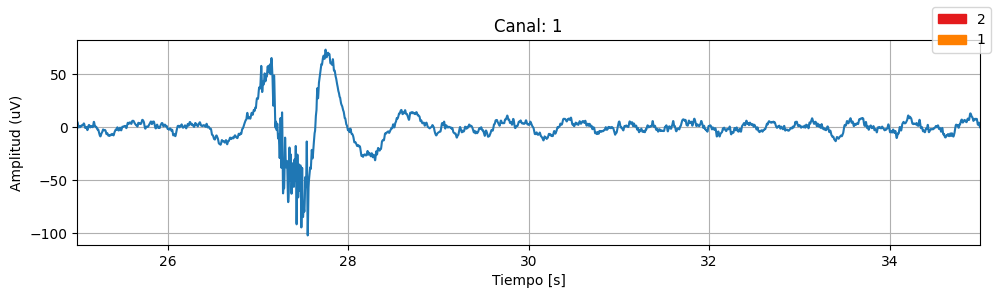

In [143]:
emg_filtrada.plot(start=25, duration=10, show_anotaciones=True)

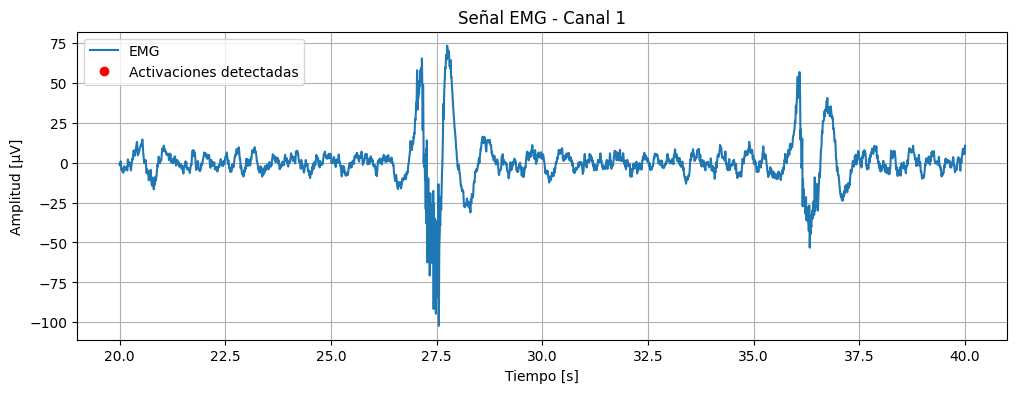

In [144]:
emg_filtrada.plot_activaciones(canal="1",start_time=20, end_time=40)

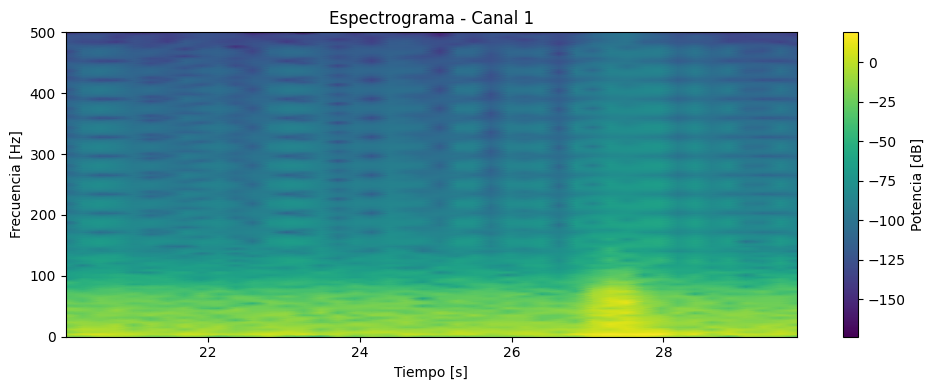

In [145]:
emg_filtrada.plot_spectrogram(canal="1", start_time=20, end_time=30)

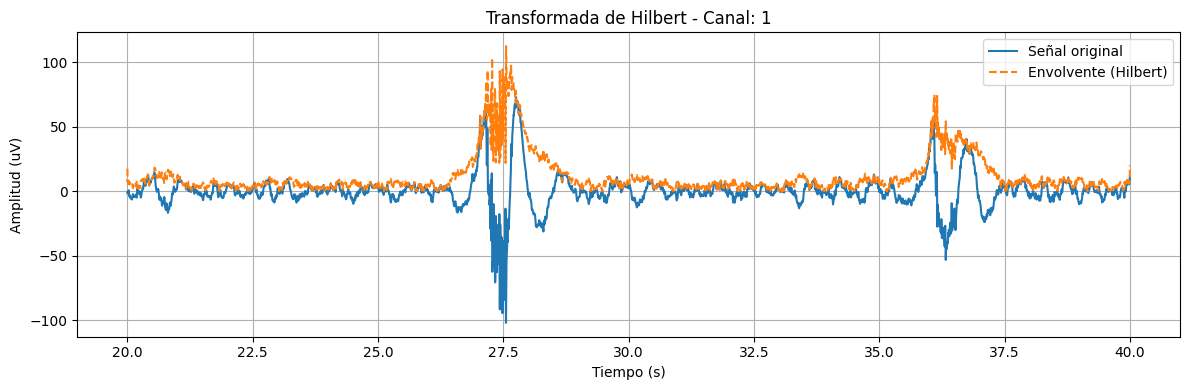

array([[-1.14690972+17.49078429j, -0.88416776+10.18741046j,
        -0.65457526+10.52534783j, ...,  9.97018222 +8.94064978j,
        10.326576   +9.31086102j, 10.55147233+17.23734674j]])

In [146]:
emg_filtrada.plot_hilbert(picks=["1"], tmin=20, tmax= 40)